In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv('1-heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df2=df.copy()
df2.isna().sum() #NO NULL
df2.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [4]:
df2.shape

(303, 14)

Data Cleaning

In [5]:
df2.duplicated().sum()
df2=df2.drop_duplicates()

In [6]:
df2.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [8]:
#EDA

In [9]:
df2.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Exploratory Data Analysis (EDA)

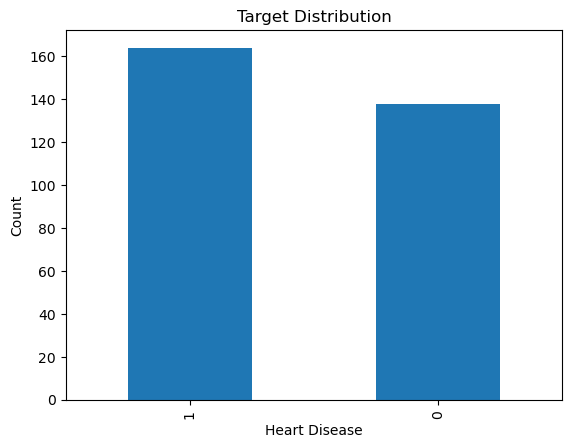

In [10]:
df2['target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

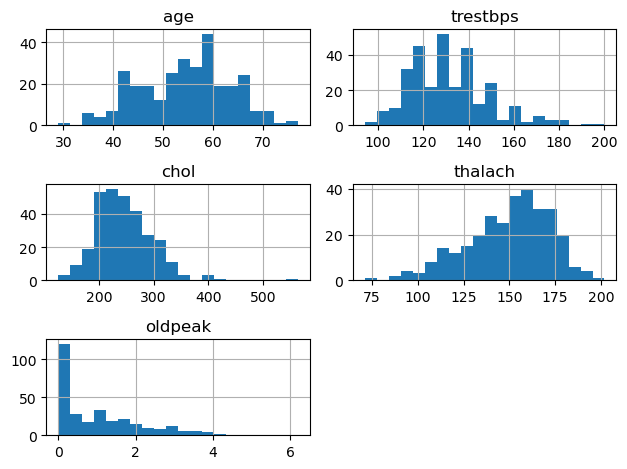

In [11]:
nums_col=['age','trestbps','chol','thalach','oldpeak']
df2[nums_col].hist(bins=20)
plt.tight_layout()

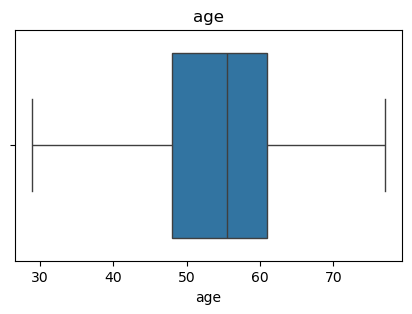

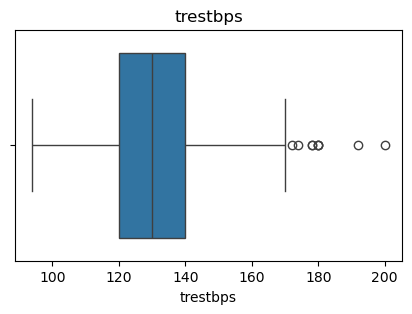

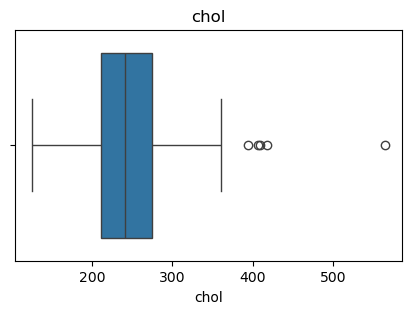

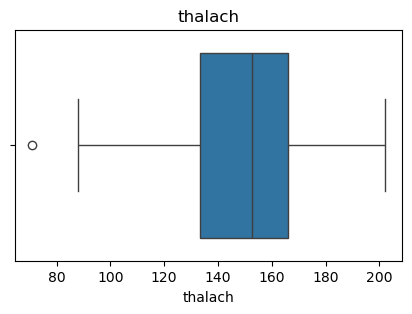

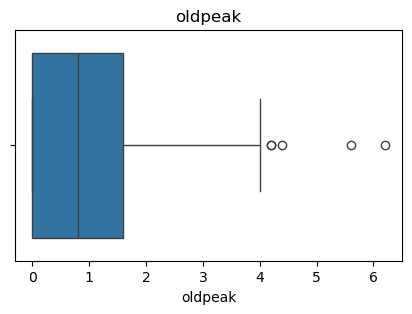

In [12]:
for col in nums_col:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df2[col])
    plt.title(col)
    plt.show()

CORRELATION HEATMAP

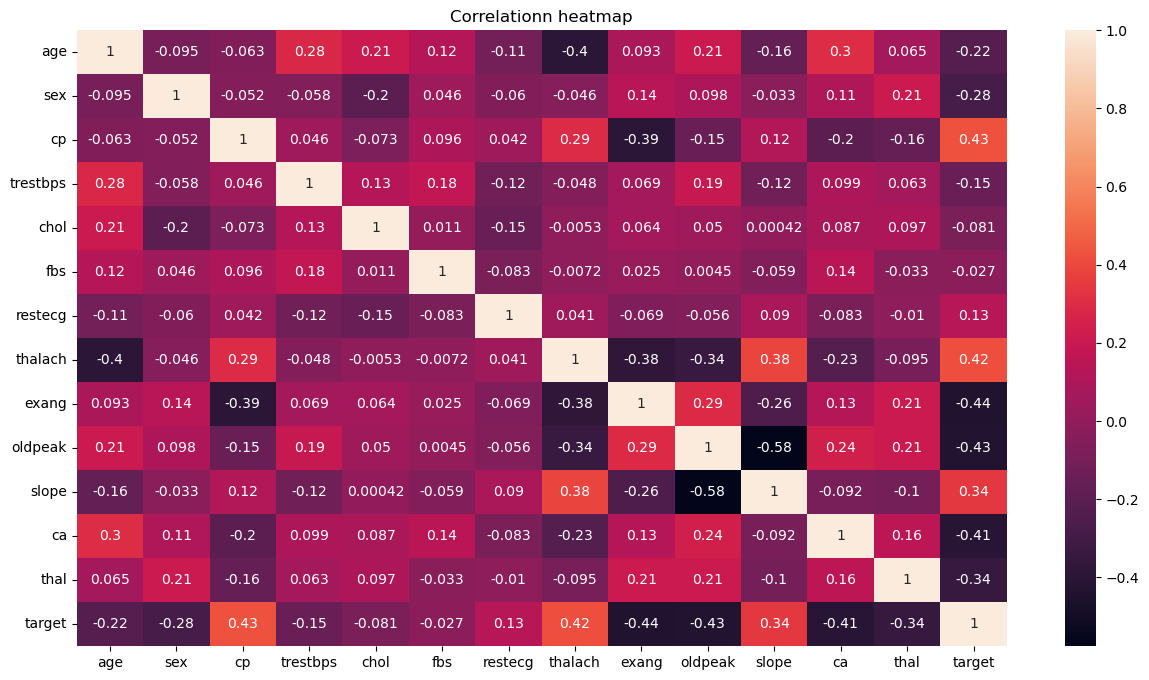

In [13]:
plt.figure(figsize=(15,8))
sns.heatmap(df2.corr(),annot=True)
plt.title('Correlationn heatmap')
plt.show()

In [14]:
for col in df2.columns:
    print(f"{col}: {df2[col].nunique()} unique values")

age: 41 unique values
sex: 2 unique values
cp: 4 unique values
trestbps: 49 unique values
chol: 152 unique values
fbs: 2 unique values
restecg: 3 unique values
thalach: 91 unique values
exang: 2 unique values
oldpeak: 40 unique values
slope: 3 unique values
ca: 5 unique values
thal: 4 unique values
target: 2 unique values


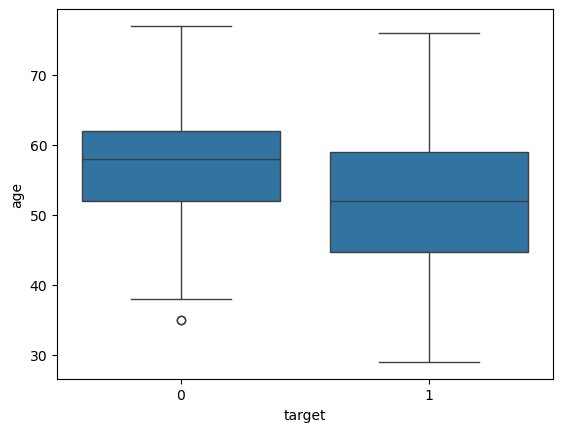

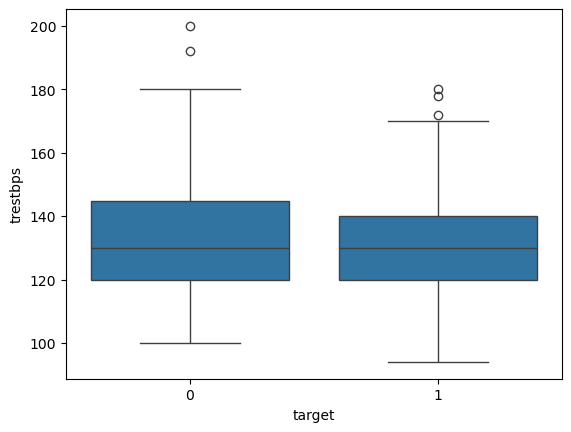

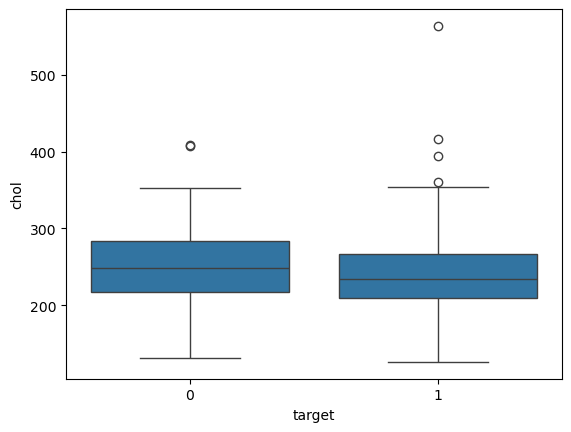

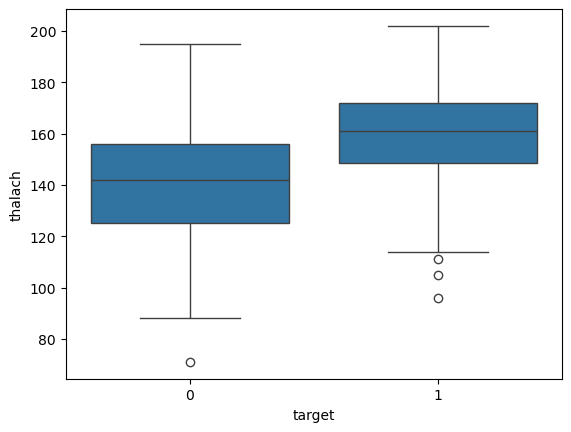

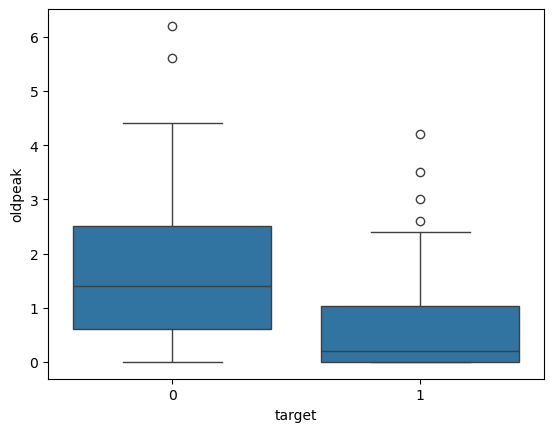

In [15]:
#AGE V/S TARGET  TRESTBPS V/S TARGET  CHOL V/S TARGET  THALACH V/S TARGET   OLDPEAK V/S TARGET
sns.boxplot(x='target',y='age',data=df2)
plt.show()
sns.boxplot(x='target',y='trestbps',data=df2)
plt.show()
sns.boxplot(x='target',y='chol',data=df2)
plt.show()
sns.boxplot(x='target',y='thalach',data=df2)
plt.show()
sns.boxplot(x='target',y='oldpeak',data=df2)
plt.show()

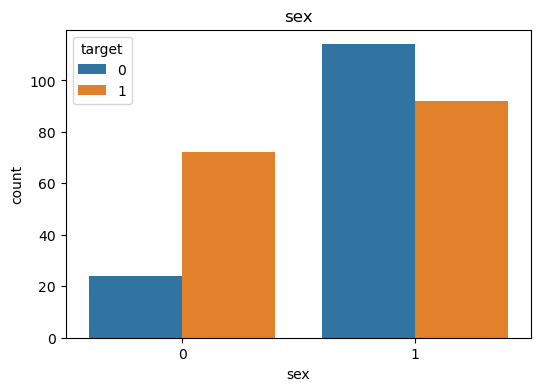

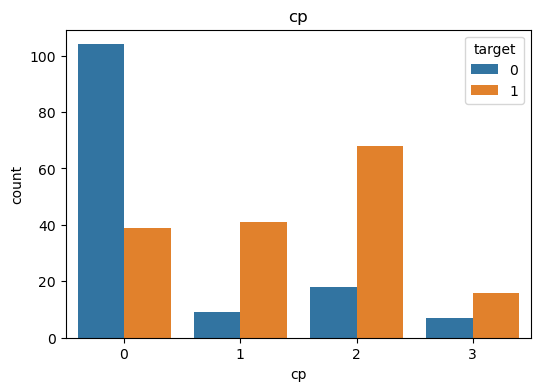

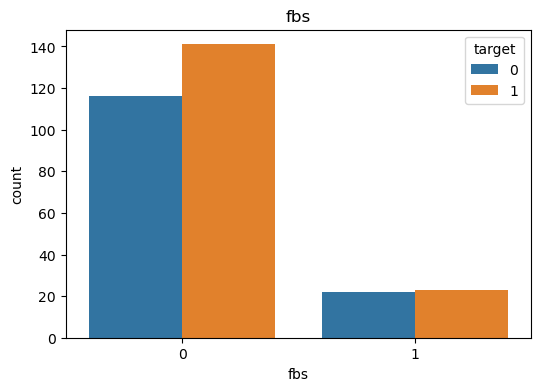

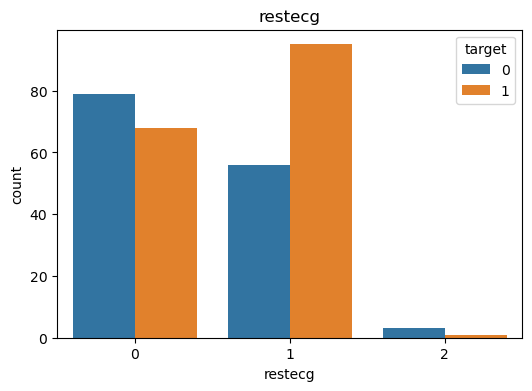

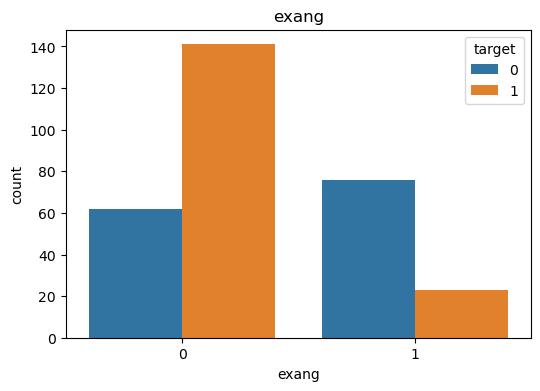

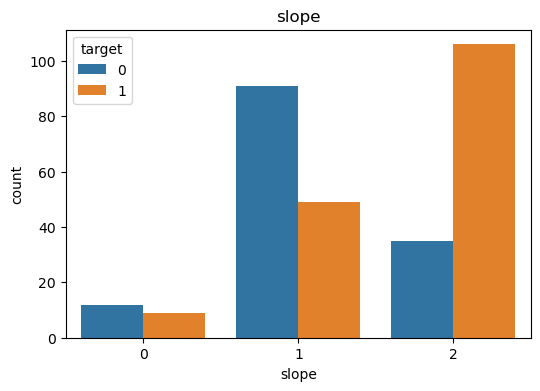

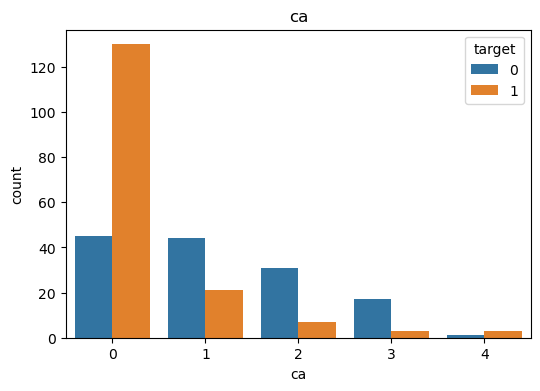

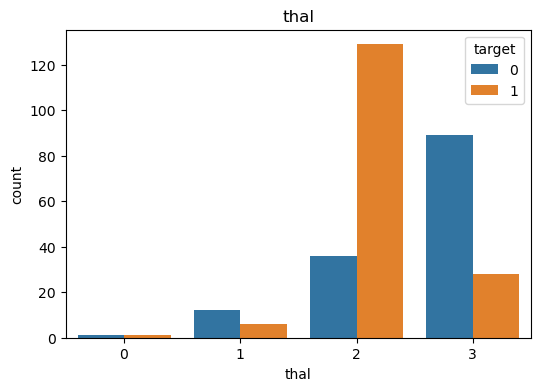

In [16]:
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df2, x=col, hue='target')
    plt.title(col)
    plt.show()

SPLITTING THE DATASET

In [17]:
X=df2.drop('target',axis=1)
y=df2['target']

In [18]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [19]:
X=pd.get_dummies(X,columns=cat_cols,drop_first=True)

In [20]:
#SPLIT DATASET
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])


MODEL EVALUATION

In [21]:
model=LogisticRegression(random_state=42)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred=model.predict(X_test)
print(y_pred)

[0 0 0 1 0 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 0 0 1 1 0 0 1 0
 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1]


CONFUSION MATRIX

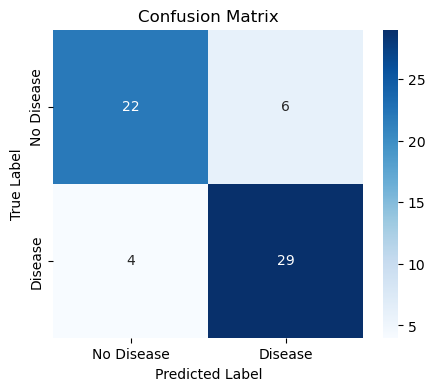

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [24]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(accuracy*100)

83.60655737704919


In this project, a Logistic Regression model was developed to predict the presence of heart disease using patient health data. The dataset was preprocessed by removing duplicates, encoding categorical variables, scaling numerical features, and splitting the data into training and testing sets. The trained model achieved an accuracy of approximately 83.61% on the test dataset. The classification report also showed good precision, recall, and F1-score for both classes, indicating balanced performance. Overall, the model demonstrates that Logistic Regression is an effective baseline algorithm for heart disease prediction and can assist in the early identification of patients at risk. Further improvements could be achieved by experimenting with more advanced machine learning models, feature engineering, and hyperparameter tuning.